In [1]:
#%matplotlib inline
import pathlib as pl 
import warnings
import flopy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

c:\Users\lima0055\anaconda3\envs\gmdsitut\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", DeprecationWarning)

In [3]:
flopy.utils.get_modflow(":python", subset="mp7")

auto-selecting option ':python' for 'bindir'
fetched release '23.0' info from MODFLOW-ORG/executables
using previous download 'C:\Users\lima0055\Downloads\modflow_executables-23.0-win64.zip' (use 'force=True' to re-download)
extracting 1 file to 'C:\Users\lima0055\anaconda3\envs\gmdsitut\Scripts'
mp7.exe (7.2.001)
updated flopy metadata file: 'C:\Users\lima0055\AppData\Local\flopy\get_modflow.json'


In [4]:
flopy.__version__

'3.9.5'

In [5]:
name = 'pmw3'
base_ws = pl.Path("solute_transport") / name
base_ws.mkdir(exist_ok=True, parents=True)

In [6]:
prt_name = f"{name}-prt"
prt_ws = base_ws / "prt"
prt_ws.mkdir(exist_ok=True, parents=True)

In [7]:
length_units = 'meters'
time_units = 'days'

In [8]:
m_d = './pyemu/PMW-6-constantK/template/3d_injection_modeling_PMW-3'
sim = flopy.mf6.MFSimulation.load(sim_ws=m_d)
gwf = sim.get_model()

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package mlac-model...


In [9]:
prt = flopy.mf6.ModflowPrt(
    sim, 
    modelname=prt_name, 
    model_nam_file=f"{prt_name}.nam"
)

AttributeError: module 'flopy.mf6' has no attribute 'ModflowPrt'

In [1]:
import numpy as np
import flopy 
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import json
import os

c:\Users\lima0055\anaconda3\envs\gmdsitut\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [4]:
class PRTTracerSimulation: 
    #connect existing MODFLOW 6 model for particle tracking

    def __init__(self, mf6_model_path, model_name='tracer_sim'): 
        #PRT sim init

        self.mf6_model_path = mf6_model_path
        self.model_name = model_name
        self.model_ws = os.path.join(mf6_model_path, 'prt_simulation')

        os.makedirs(self.model_ws, exist_ok=True)

        #well coordinates
        self.wells = {
            'PMW-3': {
                'easting': 480770.0, 
                'northing': 4980128.0, 
                'layer': 1, #second layer BPP (zero-indexed)
                'total_mass_mg': 2024.0
            }, 
            'horizontal_well': {
                'start_easting': 480895.0,
                'start_northing': 4980117.0,
                'end_easting': 480783.0,
                'end_northing': 4980010.0, 
                'layer': 1, #BPP layer
                'diameter_m': 0.1 #REVIEW THAT
            }
        }

        #sim settings
        self.settings = {
            'steady_state_days': 14, #how many days to run to achieve heads steady state given the boundary conditions
            'tracking_days': 30, #tracking days for tracer test
            'n_particles': 5000, 
            'output_frequency_days': 0.02, #output every 0.5 hours
            'release_duration_days': 0.002, #~3 minutes for pulse
            #'sampling_schedule': self._create_sampling_schedule()
        }

        #init variables
        self.mf6_model = None 
        self.prt_model = None 
        self.grid = None 
        self.results = None 

        #self.settings['sampling_schedule'] = self._create_sampling_schedule()

    def _create_sampling_schedule(self): 
        schedule = [] 
        current_time = 0
        day = 0

        #every 30 minutes sampling interval for 1st day 
        while day < 1: 
            schedule.append(current_time)
            current_time += 0.0208333 #30 minutes in days
            day = current_time 

        #day 1~3: every hour
        intervals = [0.0416667, 0.0833333, 0.166667, 0.333333, 0.5]
        for interval in intervals: 
            while current_time < self.settings['tracking_days']: 
                schedule.append(current_time)
                current_time += interval 

        #ensuring last time point is included
        if schedule[-1] < self.settings['tracking_days']: 
            schedule.append(self.settings['tracking_days'])

        return np.unique(np.array(schedule))
    
    def load_modflow_model(self): 
        print(f'loading MODFLOW 6 model from: {self.mf6_model_path}') 

        mf6_files = [f for f in os.listdir(self.mf6_model_path) if f.endswith('.nam')]

        if not mf6_files: 
            raise FileNotFoundError(f'No MODFLOW 6 name file found in {self.mf6_model_path}')
        
        #load mf6 sim
        sim = flopy.mf6.MFSimulation.load( 
            #sim_name = self.model_name, 
            exe_name = 'mf6', 
            sim_ws = self.mf6_model_path
        )

        self.mf6_model = sim.get_model() 
        self.grid = self.mf6_model.modelgrid 
        #self.sim = self.mf6_model.simulation

        print(f"mf6 model loaded") 

        return self.mf6_model 
    
    def setup_hydraulic_gradient_aligned_perpendicular(self, head_difference=1.5): 
        #setup boundary conditions to create hydraulic gradient between injection well (PMW-3) and HzWell
        #creating hydraulic gradient perpendicular to the hz well line
        #entire hz well have the same head, and PMW-3 at 1.5 m higher

        print('setting up hydraulic gradient - chd')

        self._clean_simulation_packages()

        #chd_name = f'{self.model_name}_grad_chd'
        #self._cleanup_nam_file(chd_name)

        inj_layer, inj_row, inj_col = self._coords_to_grid_indices(
            self.wells['PMW-3']['easting'], 
            self.wells['PMW-3']['northing'], 
            self.wells['PMW-3']['layer']
        )

        # Get horizontal well midpoint
        hw = self.wells['horizontal_well']
        hw_mid_x = (hw['start_easting'] + hw['end_easting']) / 2
        hw_mid_y = (hw['start_northing'] + hw['end_northing']) / 2
        hw_layer, hw_row, hw_col = self._coords_to_grid_indices(
            hw_mid_x, hw_mid_y, hw['layer']
        )
        
        # Set heads
        base_head = 100.0
        hw_head = base_head - head_difference
        
        # Create CHD cells
        chd_cells = []
        
        # 1. Injection well (higher head)
        chd_cells.append([inj_layer, inj_row, inj_col, base_head])
        
        # 2. Horizontal well cells (lower head)
        n_hw_points = 20
        for i in range(n_hw_points):
            s = i / (n_hw_points - 1)
            x = hw['start_easting'] + s * (hw['end_easting'] - hw['start_easting'])
            y = hw['start_northing'] + s * (hw['end_northing'] - hw['start_northing'])
            
            hw_layer, hw_row, hw_col = self._coords_to_grid_indices(x, y, hw['layer'])
            chd_cells.append([hw_layer, hw_row, hw_col, hw_head])
        
        # Create CHD package
        nper = self._get_nper()
        chd_spd = {per: chd_cells for per in range(nper)}
        
        chd_name = f'{self.model_name}_chd'
        chd = flopy.mf6.ModflowGwfchd(
            self.mf6_model,
            stress_period_data=chd_spd,
            pname=chd_name,
            filename=f'{chd_name}.chd'
        )
        
        print(f"  Added {len(chd_cells)} CHD cells")
        print(f"  Injection: {base_head:.2f} m, Horizontal well: {hw_head:.2f} m")
        
        # Store gradient info
        self.gradient_info = {
            'type': 'perp_to_hz_well',
            'head_difference_m': head_difference,
            #'shortest_distance_m': shortest_distance,
            #'gradient_m_per_m': head_difference / shortest_distance,
            'injection_head_m': base_head,
            'hw_head_m': hw_head,
            #'closest_point_t': t_clamped,
            #'closest_point_coords': (closest_x, closest_y),
            #'perp_direction': perp_unit.tolist(),
            #'injection_side': side
        }

        return True
        
        
        

    def _clean_simulation_packages(self):
        """
        Remove CHD and WEL packages from simulation object before writing.
        This is the KEY fix - modifies what FloPy will write.
        """
        print("  Cleaning simulation packages...")

        for attr_name in dir(self.mf6_model):
            if 'chd' in attr_name.lower() or 'wel' in attr_name.lower():
                try:
                    delattr(self.mf6_model, attr_name)
                    print(f"    Removed: {attr_name}")
                except:
                    pass
        
        # Clean from simulation
        sim = self.mf6_model.simulation
        if hasattr(sim, '_packagelist'):
            sim._packagelist = [pkg for pkg in sim._packagelist 
                              if not ('chd' in pkg.lower() or 'wel' in pkg.lower())]
        
        '''# Get the simulation
        sim = self.mf6_model.simulation
        
        # Method 1: Remove from package registry
        if hasattr(sim, '_packagelist'):
            # Filter out CHD and WEL packages
            original_count = len(sim._packagelist)
            sim._packagelist = [pkg for pkg in sim._packagelist 
                            if not ('chd' in pkg.lower() or 'wel' in pkg.lower())]
            new_count = len(sim._packagelist)
            print(f"    Removed {original_count - new_count} packages from _packagelist")
        
        # Method 2: Remove from package dict
        if hasattr(sim, 'package_key_dict'):
            keys_to_remove = []
            for key, pkg_list in sim.package_key_dict.items():
                if 'chd' in key.lower() or 'wel' in key.lower():
                    keys_to_remove.append(key)
            
            for key in keys_to_remove:
                del sim.package_key_dict[key]
                print(f"    Removed from package_key_dict: {key}")
        
        # Method 3: Remove individual packages
        packages_to_remove = []
        for attr_name in dir(sim):
            if 'chd' in attr_name.lower() or 'wel' in attr_name.lower():
                packages_to_remove.append(attr_name)
        
        for attr_name in packages_to_remove:
            try:
                delattr(sim, attr_name)
                print(f"    Removed simulation attribute: {attr_name}")
            except:
                pass
        
        # Also clean from flow model
        for attr_name in dir(self.mf6_model):
            if 'chd' in attr_name.lower() or 'wel' in attr_name.lower():
                try:
                    delattr(self.mf6_model, attr_name)
                    print(f"    Removed model attribute: {attr_name}")
                except:
                    pass'''


    def _cleanup_nam_file(self, new_chd_name):
        """
        Clean .nam file - remove all CHD and WEL entries, add new CHD.
        """
        nam_file_path = os.path.join(self.mf6_model_path, f'MLAC-model.nam')
        
        if not os.path.exists(nam_file_path):
            print(f"  .nam file not found: {nam_file_path}")
            return False
        
        print(f"  Cleaning .nam file...")
        
        try:
            # Read all lines
            with open(nam_file_path, 'r') as f:
                lines = f.readlines()
            
            # Process lines
            output_lines = []
            chd_removed = 0
            wel_removed = 0
            
            for line in lines:
                stripped = line.strip()
                
                # Keep comments and empty lines
                if not stripped or stripped.startswith('#'):
                    output_lines.append(line)
                    continue
                
                # Parse package entry
                parts = stripped.split()
                if len(parts) >= 3:
                    pkg_type = parts[0].upper()
                    
                    if pkg_type == 'CHD6':
                        chd_removed += 1
                        print(f"    Removing CHD: {parts[2]}")
                        continue  # Skip this line
                    elif pkg_type == 'WEL6':
                        wel_removed += 1
                        print(f"    Removing WEL: {parts[2]}")
                        continue  # Skip this line
                    else:
                        output_lines.append(line)
                else:
                    output_lines.append(line)
            
            # Add our new CHD entry
            new_chd_line = f"chd6  {new_chd_name}.chd\n"
            output_lines.append(new_chd_line)
            print(f"    Adding new CHD: {new_chd_name}.chd")
            
            # Write back
            with open(nam_file_path, 'w') as f:
                f.writelines(output_lines)
            
            print(f"    Removed {chd_removed} CHD and {wel_removed} WEL entries")
            
            # Delete old CHD and WEL files
            #self._delete_old_package_files(['.chd', '.wel'])
            
            return True
            
        except Exception as e:
            print(f"    Error cleaning .nam file: {e}")
            return False

    
    def _coords_to_grid_indices(self, easting, northing, layer=None): 
        #use intersect
        ij = self.grid.intersect(easting, northing)

        if layer is not None: 
            return (layer, ij[0], ij[1])
        return (ij[0], ij[1])
    
    def create_horizontal_well_sampler(self): 
        #create a line sampler for the hz well
        #this return cels along the line within capture radius

        #start and end points
        x1, y1 = self.wells['horizontal_well']['start_easting'], self.wells['horizontal_well']['start_northing']
        x2, y2 = self.wells['horizontal_well']['end_easting'], self.wells['horizontal_well']['end_northing']

        layer = self.wells['horizontal_well']['layer']
        radius = self.wells['horizontal_well']['diameter_m'] / 2

        #create line points
        n_points = 100 
        x_line = np.linspace(x1, x2, n_points)
        y_line = np.linspace(y1, y2, n_points)

        sampler_cells = []
        for xp, yp in zip(x_line, y_line): 
            row, col = self._coords_to_grid_indices(xp, yp)

            #cell center
            cell_x = self.grid.xcellcenters[row, col]
            cell_y = self.grid.ycellcenters[row, col]

            #check if the sampled coords is within radius
            distance = np.sqrt((cell_x - xp)**2 + (cell_y - yp)**2)
            if distance <= radius: 
                if (layer, row, col) not in sampler_cells: 
                    sampler_cells.append((layer, row, col))
                
        print(f'horizontal well with {len(sampler_cells)} cells')
        return sampler_cells
    
    def setup_prt_model(self): 
        print("setting up PRT model")

        gwf_name = self.mf6_model.name
        prt_name = f'{self.model_name}-prt'

        sim = self.mf6_model.simulation


        inj_layer, inj_row, inj_col = self._coords_to_grid_indices(
            self.wells['PMW-3']['easting'], 
            self.wells['PMW-3']['northing'], 
            self.wells['PMW-3']['layer']
        )

        '''#starting a MODFLOW 6 simulation
        prt_sim = flopy.mf6.MFSimulation(
            sim_name=self.model_name, 
            exe_name="mf6", 
            version="mf6", 
            sim_ws=self.mf6_model_path
        )'''

        #creating PRT sim
        prt_sim = flopy.mf6.ModflowPrt(
            simulation = sim, 
            modelname = prt_name, 
            model_nam_file = f'{prt_name}.nam'
        )

        #creating tdis
        nper = 1 #1 stress period
        tdis = flopy.mf6.modflow.mftdis.ModflowTdis(
            #prt_sim, #do not work
            self.mf6_model.simulation,
            pname="prt-tdis",
            time_units="DAYS",
            nper=nper,
            perioddata=[
                (self.settings['tracking_days'],  # PERLEN: 30 days
                1440,      # NSTP: 1440 timesteps (0.02083333 day = 0.5 hours each)
                1.0)      # TSMULT: 1.0
            ],
        )

        

        #dis
        #prt_dis = flopy.mf6.ModflowPrtDis(
        '''prt_dis = flopy.mf6.modflow.mfgwfdis.ModflowGwfdis(
            prt_sim, 
            nlay=self.grid.nlay, 
            nrow=self.grid.nrow, 
            ncol=self.grid.ncol, 
            delr=self.grid.delr, 
            delc=self.grid.delc, 
            top=self.grid.top, 
            botm=self.grid.botm, 
            idomain=self.mf6_model.dis.idomain.array if hasattr(self.mf6_model.dis, 'idomain') else 1
        )'''

        #prt mip
        porosity = 0.05
        prt_mip = flopy.mf6.ModflowPrtmip(
            prt_sim, 
            pname="mip", 
            porosity=porosity, 
            #zone=1
        )


        '''#PRT fmi - model interface
        prt_fmi = flopy.mf6.ModflowPrtFmi(
            prt_sim, 
            #flowimbalancecsv=None, 
            pname="fmi",
            packagedata=[('GWFBUDGET', gwf_name)]
        )'''

        #calculate particle mass
        total_mass_kg = self.wells['PMW-3']['total_mass_mg'] / 1e6 #from mg to kg
        particle_mass = total_mass_kg / self.settings['n_particles']

        #release location
        release_data = []
        for i in range(self.settings['n_particles']):

            release_data.append(
                (i, #particle index
                #self.grid.get_node([(inj_layer,inj_row,inj_col)])[0], #node
                inj_layer, inj_row, inj_col, #release index (?), lyr, row, col
                self.wells['PMW-3']['easting'], self.wells['PMW-3']['northing'], 
                0.5 #center of cell
                #particle_mass, 
                #self.settings['release_duration_days']
                )
            )


        #prt release
        prp = flopy.mf6.ModflowPrtprp(
            prt_sim,
            pname="prp1",
            filename="{}_1.prp".format(prt_name),
            nreleasepts=len(release_data),
            packagedata=release_data,
            perioddata={1: ["FIRST"]}, #particles will be released at the first timestep of the second stress period
            #nreleasetimes=len(release_times),
            #releasetimes=[(t,) for t in release_times],
            # local z coordinates specified, compute global release
            # coord from cell top if saturated or water table if not
            local_z=True,
            exit_solve_tolerance=1e-5,
            #extend_tracking=True,
        )
        '''prt_rls = flopy.mf6.ModflowPrtRls(
            prt_sim, 
            maxbound=len(release_data), #(?)
            packagedata=release_data
        )'''

        #prt tim (time integration)
        '''prt_tim = flopy.mf6.ModflowPrtTim(
            prt_sim, 
            pname="tim", 
            timeintegration='EULER', 
            tracktimestep='AUTO', 
            tracktime=True, 
            stoptime=self.settings['tracking_days'], 
            timeunits='DAYS'
        )'''

        #prt output
        track_times = np.linspace(0, self.settings['tracking_days'], 100).tolist()
        
        trackcsvfile_prt = f"{prt_name}.trk.csv"
        prt_oc = flopy.mf6.ModflowPrtoc(
            prt_sim,
            pname="oc",
            trackcsv_filerecord=[trackcsvfile_prt],
            track_release=True,
            track_terminate=True,
            track_usertime=True,
            ntracktimes=len(track_times),
            tracktimes=[(t,) for t in track_times],
            #saverecord=[("BUDGET", "ALL")]
        )

        #gwf-prt exchange

        exg = flopy.mf6.ModflowGwfprt(
            sim, 
            exgtype="GWF6-PRT6",
            exgmnamea=gwf_name, 
            exgmnameb=prt_name, 
            filename=f"{gwf_name}.gwfprt"
        )

        #prt ems (solution)
        prt_ems = flopy.mf6.ModflowEms(
            prt_sim,
            pname="ems",
            filename=f"{gwf_name}.ems",
        )
        

        '''#creating observation package for horizontal well
        sampler_cells = self.create_horizontal_well_sampler()
        if sampler_cells: 
            obs_data = []
            for i, (layer, row, col) in enumerate(sampler_cells): 
                obs_data.append((f'HZ_{i}', 'CELL', layer, row, col))

            prt_obs = flopy.mf6.ModflowPrtObs(
                prt_sim, 
                digits=10, 
                print_input=True, 
                continuous={'hz_breakthrough.csv'}
            )'''
        
        
        sim.register_solution_package(prt_ems, [prt_sim.name])
        
        self.prt_model = prt_sim 
        print('PRT model setup completed')

        return prt_sim, release_data

    def modify_existing_tdis_for_steady_state(self):
        """
        Modify the existing TDIS to run for 14 days steady state.
        """
        print("  Modifying TDIS for steady state...")
        
        # Get the simulation
        sim = self.mf6_model.simulation
        
        # Get existing TDIS
        tdis = sim.tdis
        
        # MODIFY IT: Create new perioddata for 14 days steady state
        # Option A: Single steady state period
        new_perioddata = [
            (self.settings['steady_state_days'], 1, 1.0),  # 14 days, 1 timestep
            (self.settings['tracking_days'], 1440, 1.0)    #30 days, 1440 timesteps tracer test
        ]
        
        # Option B: Keep original periods but modify first one
        # This depends on your original TDIS structure
        
        # Update TDIS
        tdis.nper = len(new_perioddata)
        tdis.perioddata = new_perioddata
        
        print(f"    Updated TDIS: {len(new_perioddata)} period(s), "
            f"{self.settings['steady_state_days']} days steady state")
    
    def run_modflow_steady_state(self, head_difference): 
        print('setting boundary conditions')
        self.setup_hydraulic_gradient_aligned_perpendicular(
            head_difference=head_difference
        )

        #self.plot_gradient_setup() ##### THIS FUNCTION NEED TO BE UPDATED TO WORK PROPERLY

        print('running MODFLOW 6 for obtaining steady state heads')

        #self.mf6_model.simulation.write_simulation()

        #success, buff = self.mf6_model.simulation.run_simulation(silent=False)

        '''if not success: 
            print('MODFLOW 6 run failed')
            print(buff)
            return False'''
        
        print('MODFLOW 6 steady state complete')
        return True
    
    def run_prt_simulation(self): 
        print('running PRT sim')

        self.mf6_model.simulation.write_simulation()
        success, buff = self.mf6_model.simulation.run_simulation(silent=False) 

        #self.prt_model.simulation.write_simulation()
        #success, buff = self.prt_model.simulation.run_simulation(silent=False) 

        if not success: 
            print('PRT sim failed')
            print(buff)
            return False
        
        print('PRT sim complete')
        return True
    
    def load_results(self): 
        print('loading results')
        '''results = {
            'particle_data': None, 
            'breakthrough': None, 
            'travel_times': None, 
            'pathlines': None
        }

        particle_csv = os.path.join(self.model_ws, f'{self.model_name}_particles.csv')
        if os.path.exists(particle_csv): 
            results['particle_data'] = pd.read_csv(particle_csv)
            print('loaded particle csv file')

        bt_csv = os.path.join(self.model_ws, 'hz_breakthrough.csv')
        if os.path.exists(bt_csv): 
            results['breakthrough'] = pd.read_csv(bt_csv)
            print('loaded btc csv file')

        if results['particle_data'] is not None: 
            #group by particle and get first/last times
            particle_times = results['particle_data'].groupby('particleid')['time'].agg(['min', 'max'])
            results['travel_times'] = particle_times['max'] - particle_times['min']

            print(f"calculated travel times for {len(results['travel_times'])} particles")

        self.results = results'''

        prt_name = f"{self.model_name}-prt"
        track_file = os.path.join(self.model_ws, f"{prt_name}.trk.csv")
        
        if os.path.exists(track_file):
            self.results = pd.read_csv(track_file)
            print(f"✓ Loaded {len(self.results)} particle records")
        else:
            print(f"✗ Results file not found: {track_file}")
        
        results = self.results
        return results
    
    def calculate_breakthrough_curve(self, bin_width_days=0.1): 
        #BTC at hz well
        #dataframe: time, cumulative_particles, concentration

        if self.results is None or self.results['breakthrough'] is None: 
            print('No BTC data available')
            return None
        
        bt_data = self.results['breahthrough']

        time_bins = np.arange(0, self.settings['tracking_days'] + bin_width_days, bin_width_days) 
        #counting arrivals
        arrivals, _ = np.histogram(bt_data['time'], bins=time_bins)
        cumulative = np.cumsum(arrivals)

        #converting to concentration
        total_particles = self.settings['n_particles']
        total_mass_kg = self.wells['PMW-3']['total_mass_mg'] / 1e6

        if total_particles > 0: 
            concentration = (cumulative / total_particles) * total_mass_kg
        else: 
            concentration = np.zeros_like(cumulative)

        #creating dataframe
        breakthrough_df = pd.DataFrame({
            'time_days': time_bins[:-1], 
            'arrival_rate': arrivals / bin_width_days, #particles per day
            'cumulative_particles': cumulative, 
            'cumulative_mass_kg': cumulative * (total_mass_kg / total_particles), 
            'concentration_kg': concentration
        })

        return breakthrough_df

    def visualize_results(self):
        if self.results is None: 
            print('no results to plot')
            return
        
        fig = plt.figure(figsize=(15, 10))

        ax1 = fig.add_subplot(2, 3, 1)
        self._plot_pathlines_map(ax1)
        
        ax2 = fig.add_subplot(2, 3, 2)
        self._plot_breakthrough_curve(ax2)
        
        ax3 = fig.add_subplot(2, 3, 3)
        self._plot_travel_time_distribution(ax3)
        
        ax4 = fig.add_subplot(2, 3, 4)
        self._plot_particle_positions(ax4)
        
        ax5 = fig.add_subplot(2, 3, 5)
        self._plot_horizontal_well_arrivals(ax5)
        
        ax6 = fig.add_subplot(2, 3, 6)
        self._plot_model_info(ax6)
        ax6.axis('off')
        
        plt.tight_layout()
        plt.show()

    def _plot_pathlines_map(self, ax):
        #plotting particle pathlines in map view
        if self.results is None or self.results['particle_data'] is None:
            ax.text(0.5, 0.5, 'No pathline data', ha='center', va='center')
            return
        
        # Sample some particles for clarity
        particle_ids = np.random.choice(
            self.results['particle_data']['particleid'].unique(),
            size=min(100, len(self.results['particle_data']['particleid'].unique())),
            replace=False
        )
        
        for pid in particle_ids:
            particle = self.results['particle_data'][
                self.results['particle_data']['particleid'] == pid
            ]
            ax.plot(particle['x'], particle['y'], 'b-', alpha=0.1, linewidth=0.5)
        
        ax.plot(self.wells['PMW-3']['easting'], 
                self.wells['PMW-3']['northing'], 
                'ro', markersize=10, label='Injection')
        
        # Plot horizontal well
        hw = self.wells['horizontal_well']
        ax.plot([hw['start_easting'], hw['end_easting']],
                [hw['start_northing'], hw['end_northing']],
                'g-', linewidth=3, label='Horizontal Well')
        
        ax.set_xlabel('Easting (m)')
        ax.set_ylabel('Northing (m)')
        ax.set_title('Particle Pathlines')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')

    def _plot_breakthrough_curve(self, ax):
        #plotting BTC
        breakthrough_df = self.calculate_breakthrough_curve()
        
        if breakthrough_df is not None:
            ax.plot(breakthrough_df['time_days'], 
                   breakthrough_df['cumulative_mass_kg'] * 1e6,  # Convert to mg
                   'b-', linewidth=2, label='Cumulative mass')
            
            ax2 = ax.twinx()
            ax2.plot(breakthrough_df['time_days'],
                    breakthrough_df['arrival_rate'],
                    'r--', alpha=0.7, label='Arrival rate')
            
            ax.set_xlabel('Time (days)')
            ax.set_ylabel('Cumulative Mass (mg)', color='b')
            ax2.set_ylabel('Arrival Rate (particles/day)', color='r')
            ax.set_title('Breakthrough Curve')
            ax.grid(True, alpha=0.3)
            
            # Add legend
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    def _plot_travel_time_distribution(self, ax):
        #plotting travel time distribution
        if self.results is None or self.results['travel_times'] is None:
            ax.text(0.5, 0.5, 'No travel time data', ha='center', va='center')
            return
        
        travel_times = self.results['travel_times']
        
        ax.hist(travel_times, bins=30, edgecolor='black', alpha=0.7)
        ax.set_xlabel('Travel Time (days)')
        ax.set_ylabel('Frequency')
        ax.set_title('Travel Time Distribution')
        ax.grid(True, alpha=0.3)
        
        # Add statistics
        stats_text = f"""
        Min: {travel_times.min():.2f} days
        Max: {travel_times.max():.2f} days
        Mean: {travel_times.mean():.2f} days
        Median: {travel_times.median():.2f} days
        """
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
                fontsize=9, verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
    def _plot_particle_positions(self, ax):
        #plotting particle positions at different times
        if self.results is None or self.results['particle_data'] is None:
            ax.text(0.5, 0.5, 'No particle data', ha='center', va='center')
            return
        
        #select time snapshots
        times = np.linspace(0, self.settings['tracking_days'], 6)
        
        for i, t in enumerate(times):
            # Get particles near this time
            time_data = self.results['particle_data']
            time_mask = np.abs(time_data['time'] - t) < 0.1
            
            if time_mask.any():
                subset = time_data[time_mask]
                ax.scatter(subset['x'], subset['y'], 
                          s=10, alpha=0.5, label=f't={t:.1f} days')
        
        ax.set_xlabel('Easting (m)')
        ax.set_ylabel('Northing (m)')
        ax.set_title('Particle Positions Over Time')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')

    def _plot_horizontal_well_arrivals(self, ax):
        #plotting particle arrivals along horizontal well
        if self.results is None or self.results['breakthrough'] is None:
            ax.text(0.5, 0.5, 'No breakthrough data', ha='center', va='center')
            return
        
        bt_data = self.results['breakthrough']
        
        # getting positions along horizontal well
        hw = self.wells['horizontal_well']
        x_positions = bt_data['x']
        y_positions = bt_data['y']
        
        # calculating distance along well
        #projecting points onto well line
        well_vector = np.array([hw['end_easting'] - hw['start_easting'],
                               hw['end_northing'] - hw['start_northing']])
        well_length = np.linalg.norm(well_vector)
        well_unit = well_vector / well_length
        
        arrival_positions = []
        for x, y in zip(x_positions, y_positions):
            point_vector = np.array([x - hw['start_easting'],
                                    y - hw['start_northing']])
            #project onto well line
            projection = np.dot(point_vector, well_unit)
            arrival_positions.append(projection)
        
        arrival_positions = np.array(arrival_positions)
        
        ax.scatter(arrival_positions, bt_data['time'], 
                  c=bt_data['time'], cmap='viridis', s=10, alpha=0.6)
        ax.set_xlabel('Distance along well (m)')
        ax.set_ylabel('Arrival Time (days)')
        ax.set_title('Arrivals at Horizontal Well')
        ax.grid(True, alpha=0.3)
        
        plt.colorbar(ax.collections[0], ax=ax, label='Arrival Time (days)')

    def _plot_model_info(self, ax):
        #display model information
        info_text = f"""
        Model: {self.model_name}
        Grid: {self.grid.nlay}L × {self.grid.nrow}R × {self.grid.ncol}C
        Cells: {self.grid.nlay * self.grid.nrow * self.grid.ncol:,}
        
        Injection Well:
          Easting: {self.wells['PMW-3']['easting']:.1f}
          Northing: {self.wells['PMW-3']['northing']:.1f}
          Layer: {self.wells['PMW-3']['layer'] + 1}
          Mass: {self.wells['PMW-3']['total_mass_mg']} mg
        
        Horizontal Well:
          Length: {np.sqrt((self.wells['horizontal_well']['end_easting'] - 
                           self.wells['horizontal_well']['start_easting'])**2 +
                          (self.wells['horizontal_well']['end_northing'] - 
                           self.wells['horizontal_well']['start_northing'])**2):.1f} m
          Layer: {self.wells['horizontal_well']['layer'] + 1}
          Diameter: {self.wells['horizontal_well']['diameter_m']*100:.1f} cm
        
        Simulation:
          Particles: {self.settings['n_particles']:,}
          Tracking: {self.settings['tracking_days']} days
          Output: every {self.settings['output_frequency_days']*24:.1f} hours
        """
        
        ax.text(0.05, 0.95, info_text, transform=ax.transAxes,
                fontsize=9, verticalalignment='top',
                family='monospace')
        
    def plot_gradient_setup(self):
        """Plot the gradient setup geometry."""
        import matplotlib.pyplot as plt
        
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Plot model grid (sample)
        if hasattr(self.grid, 'xcellcenters'):
            # Plot every 5th cell for clarity
            for i in range(0, self.grid.nrow, 5):
                for j in range(0, self.grid.ncol, 5):
                    x = self.grid.xcellcenters[i, j]
                    y = self.grid.ycellcenters[i, j]
                    ax.plot(x, y, 'k.', markersize=1, alpha=0.3)
        
        # Plot PMW-3 well
        inj_x = self.wells['PMW-3']['easting']
        inj_y = self.wells['PMW-3']['northing']
        ax.plot(inj_x, inj_y, 'ro', markersize=12, label='Injection Well', zorder=10)
        ax.text(inj_x, inj_y, ' INJ', fontsize=10, va='center')
        
        # Plot horizontal well line
        hw = self.wells['horizontal_well']
        ax.plot([hw['start_easting'], hw['end_easting']],
                [hw['start_northing'], hw['end_northing']],
                'b-', linewidth=3, label='Horizontal Well', zorder=5)
        
        # Mark start and end
        ax.plot(hw['start_easting'], hw['start_northing'], 'b^', markersize=8, label='HW Start')
        ax.plot(hw['end_easting'], hw['end_northing'], 'bv', markersize=8, label='HW End')
        
        # Plot closest point on HW
        if hasattr(self, 'gradient_info'):
            closest_x, closest_y = self.gradient_info['closest_point_coords']
            ax.plot(closest_x, closest_y, 'go', markersize=10, 
                    label='Closest Point on HW', zorder=9)
            
            # Draw perpendicular line
            perp = self.gradient_info['perp_direction']
            scale = 50  # meters
            ax.arrow(closest_x, closest_y, 
                    perp[0]*scale, perp[1]*scale,
                    head_width=5, head_length=5, fc='g', ec='g',
                    label='Perpendicular Direction')
            
            # Draw injection to closest point line
            ax.plot([inj_x, closest_x], [inj_y, closest_y], 
                    'g--', linewidth=2, label=f'Shortest distance: {self.gradient_info["shortest_distance_m"]:.1f} m')
            
            # Add head labels
            ax.text(inj_x, inj_y + 5, f'h = {self.gradient_info["injection_head_m"]:.1f} m', 
                    fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
            ax.text(closest_x, closest_y - 5, f'h = {self.gradient_info["hw_head_m"]:.1f} m', 
                    fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='blue', alpha=0.3))
            
            # Calculate and display gradient
            grad = self.gradient_info['gradient_m_per_m']
            ax.text(0.05, 0.95, 
                    f'Head difference: {self.gradient_info["head_difference_m"]:.2f} m\n'
                    f'Shortest distance: {self.gradient_info["shortest_distance_m"]:.1f} m\n'
                    f'Gradient: {grad:.4f} m/m\n'
                    f'           ({grad*1000:.1f} m/km)',
                    transform=ax.transAxes, fontsize=10,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
        
        # Add scale
        ax.plot([inj_x - 50, inj_x + 50], [inj_y - 100, inj_y - 100], 'k-', linewidth=2)
        ax.plot([inj_x - 50, inj_x - 50], [inj_y - 95, inj_y - 105], 'k-', linewidth=2)
        ax.plot([inj_x + 50, inj_x + 50], [inj_y - 95, inj_y - 105], 'k-', linewidth=2)
        ax.text(inj_x, inj_y - 110, '100 m', ha='center', fontsize=9)
        
        ax.set_xlabel('Easting (m)')
        ax.set_ylabel('Northing (m)')
        ax.set_title('Hydraulic Gradient Setup: Perpendicular to Horizontal Well')
        ax.legend(loc='upper left', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        
        plt.tight_layout()
        plt.show()
        

    def export_results(self, output_path=None):
        """
        Export all results to files.
        """
        if output_path is None:
            output_path = os.path.join(self.model_ws, 'results')
        
        os.makedirs(output_path, exist_ok=True)
        
        # Export breakthrough curve
        breakthrough_df = self.calculate_breakthrough_curve()
        if breakthrough_df is not None:
            breakthrough_df.to_csv(os.path.join(output_path, 'breakthrough_curve.csv'), index=False)
        
        # Export travel times
        if self.results is not None and self.results['travel_times'] is not None:
            pd.DataFrame({
                'particle_id': self.results['travel_times'].index,
                'travel_time_days': self.results['travel_times'].values
            }).to_csv(os.path.join(output_path, 'travel_times.csv'), index=False)
        
        # Export settings
        with open(os.path.join(output_path, 'simulation_settings.json'), 'w') as f:
            json.dump({
                'wells': self.wells,
                'settings': self.settings
            }, f, indent=2)
        
        print(f"✓ Results exported to: {output_path}")

    def modify_initial_conditions(self, initial_head=100.0):
        """
        Modify initial conditions to 100m everywhere (or specified value).
        This helps with convergence for steady state.
        """
        print(f"\nModifying initial conditions to {initial_head} m everywhere...")
        
        # Check if IC package exists
        if hasattr(self.mf6_model, 'ic'):
            ic = self.mf6_model.ic
            
            # Method 1: Modify existing IC package
            if hasattr(ic, 'strt'):
                # Create new initial head array
                new_strt = np.ones((self.grid.nlay, self.grid.nrow, self.grid.ncol)) * initial_head
                ic.strt = new_strt
                print(f"  Updated IC.strt to {initial_head} m everywhere")
            
            # Method 2: Replace IC package
            else:
                # Remove old IC
                delattr(self.mf6_model, 'ic')
                
                # Create new IC
                ic = flopy.mf6.ModflowGwfic(
                    self.mf6_model,
                    pname='ic',
                    strt=initial_head
                )
                print(f"  Created new IC package with strt={initial_head} m")
        
        else:
            # Create new IC package
            ic = flopy.mf6.ModflowGwfic(
                self.mf6_model,
                pname='ic',
                strt=initial_head
            )
            print(f"  Created IC package with strt={initial_head} m")
        
        return True
    
    def modify_tdis_for_steady_state(self):
        """
        Modify TDIS to run for 14 days steady state with single period.
        """
        print("\nModifying TDIS for 14-day steady state...")
        
        # Get TDIS from simulation
        sim = self.mf6_model.simulation
        tdis = sim.tdis
        
        # Create new period data: 14 days, 1 timestep (steady state)
        new_perioddata = [
            (self.settings['steady_state_days'], 1, 1.0)  # 14 days, 1 step
        ]
        
        # Update TDIS
        tdis.nper = len(new_perioddata)
        tdis.perioddata = new_perioddata
        
        # Also update in DIS package if needed
        if hasattr(self.mf6_model.dis, 'steady_state'):
            # Mark as steady state
            self.mf6_model.dis.steady_state = {0: True}
        
        print(f"  TDIS updated: {len(new_perioddata)} period, {self.settings['steady_state_days']} days")
        print(f"  Period data: {new_perioddata}")
        
        return True


    def run_complete_simulation(self):
        """
        Run complete simulation workflow.
        """
        print("="*60)
        print("PRT TRACER SIMULATION")
        print("="*60)
        
        chd_name = 'tracer_test_sim_grad_chd'
        self._cleanup_nam_file(chd_name)

        # 1. Load MODFLOW model
        self.load_modflow_model()

        print("\nModifying MODFLOW for steady state run...")
        self.modify_initial_conditions(initial_head=100.0)
        self.modify_existing_tdis_for_steady_state()
        #self.modify_tdis_for_steady_state() #new one
        
        # 2. Run steady state
        if not self.run_modflow_steady_state(head_difference=1.5):
            return False
        
        # 3. Setup PRT
        prt, release_data = self.setup_prt_model()
        return prt
        
        # 4. Run PRT
        if not self.run_prt_simulation():
            return False
        
        # 5. Load results
        self.load_results()
        
        # 6. Export results
        self.export_results()
        
        # 7. Visualize
        self.visualize_results()
        
        print("\n" + "="*60)
        print("SIMULATION COMPLETE")
        print("="*60)
        
        return True
    
    def _get_nper(self):
        """
        Get number of stress periods.
        """
        try:
            nper = self.mf6_model.simulation.tdis.nper.array[0]
            return int(nper)
        except:
            return 1







In [5]:

mf6_folder = "C:/Users/lima0055/Documents/MLAC-3D-HT/src/pyemu/PMW-6-constantK/master_pp/3d_injection_modeling_PMW-3"
sim = PRTTracerSimulation(mf6_model_path=mf6_folder)
success = sim.run_complete_simulation()

PRT TRACER SIMULATION
  Cleaning .nam file...
    Adding new CHD: tracer_test_sim_grad_chd.chd
    Removed 0 CHD and 0 WEL entries
loading MODFLOW 6 model from: C:/Users/lima0055/Documents/MLAC-3D-HT/src/pyemu/PMW-6-constantK/master_pp/3d_injection_modeling_PMW-3
loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package oc...
    loading package obs...
  loading model prt6...
    loading package mip...
    loading package prp...
    loading package oc...
  loading model prt6...
    loading package mip...
    loading package prp...
    loading package oc...
  loading exchange package gwf-prt_exg_0...
  loading solution package mlac-model...
  loading solution package ems_0...
  loading solution package tracer_sim-prt...
mf6 model loaded

Modifying MODFLOW for steady state run...

Modifying initial conditions to 100

TypeError: 'NoneType' object is not subscriptable

In [2]:
import numpy as np
import flopy 
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import json
import os

c:\Users\lima0055\anaconda3\envs\gmdsitut\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
model_name='tracer_sim' 
mf6_model_path = "C:/Users/lima0055/Documents/MLAC-3D-HT/src/pyemu/PMW-6-constantK/master_pp_newweights_newinitialK/3d_injection_modeling_PMW-3"
k_files_path = "C:/Users/lima0055/Documents/MLAC-3D-HT/src/pyemu/PMW-6-constantK/master_pp_newweights_newinitialK"
model_ws = os.path.join(k_files_path, 'prt_simulation')
os.makedirs(model_ws, exist_ok=True)

In [3]:
gwf_name = f"{model_name}-gwf"
prt_name = f"{model_name}-prt"

In [4]:
'''mf6_files = [f for f in os.listdir(mf6_model_path) if f.endswith('.nam')]

if not mf6_files: 
    raise FileNotFoundError(f'No MODFLOW 6 name file found in {mf6_model_path}')
        
#load mf6 sim
old = flopy.mf6.MFSimulation.load( 
    #sim_name = self.model_name, 
    exe_name = 'mf6', 
    sim_ws = mf6_model_path
)

mf6_model = old.get_model() 
grid = mf6_model.modelgrid '''

"mf6_files = [f for f in os.listdir(mf6_model_path) if f.endswith('.nam')]\n\nif not mf6_files: \n    raise FileNotFoundError(f'No MODFLOW 6 name file found in {mf6_model_path}')\n\n#load mf6 sim\nold = flopy.mf6.MFSimulation.load( \n    #sim_name = self.model_name, \n    exe_name = 'mf6', \n    sim_ws = mf6_model_path\n)\n\nmf6_model = old.get_model() \ngrid = mf6_model.modelgrid "

In [4]:
nper = 2  # Number of periods
nlay = 3
nrow_inner = 350
ncol_inner = 350
dx = 1.0 #1 meter finer cell size
dy = dx
dx_outer = [1.5 ** i for i in range(1, 20)]
dy_outer = dx_outer
delr = dx_outer[::-1] + ncol_inner * [dx] + dx_outer
delc = dy_outer[::-1] + nrow_inner * [dy] + dy_outer
delr = np.array(delr)
delc = np.array(delc)
nrow = delc.shape[0]
ncol = delr.shape[0]
top = 0. * 0.3048 #ft to meters
top = top * np.ones((nrow, ncol), dtype=float)
botm = -30. * 0.3048 #ft to meters (30ft thick)
botm = botm * np.ones((nlay, nrow, ncol), dtype=float)

botm_dis = [-14. * 0.3048, -16. * 0.3048, -30. * 0.3048 ] #defining bottom of each layer (3 layers)
for layer in range(nlay): 
    botm[layer] = botm_dis[layer]
    
porosity = 0.0016  # aquifer porosity (unitless)
'''
top = 30. * 0.3048 #ft to meters
top = top * np.ones((nrow, ncol), dtype=float)
botm = -30. * 0.3048 #ft to meters (30ft thick)
botm = botm * np.ones((nlay, nrow, ncol), dtype=float)

botm_dis = [16. * 0.3048, 14. * 0.3048, 0. * 0.3048 ] #defining bottom of each layer (3 layers)
for layer in range(nlay): 
    botm[layer] = botm_dis[layer]'''

'\ntop = 30. * 0.3048 #ft to meters\ntop = top * np.ones((nrow, ncol), dtype=float)\nbotm = -30. * 0.3048 #ft to meters (30ft thick)\nbotm = botm * np.ones((nlay, nrow, ncol), dtype=float)\n\nbotm_dis = [16. * 0.3048, 14. * 0.3048, 0. * 0.3048 ] #defining bottom of each layer (3 layers)\nfor layer in range(nlay): \n    botm[layer] = botm_dis[layer]'

In [5]:
settings = {
            'steady_state_days': 14, #how many days to run to achieve heads steady state given the boundary conditions
            'tracking_days': 60, #tracking days for tracer test
            'n_particles': 5000, 
            'output_frequency_days': 0.02, #output every 0.5 hours
            'release_duration_days': 0.002, #~3 minutes for pulse
        }

In [6]:
sim = flopy.mf6.MFSimulation(
    sim_name=model_name, exe_name="mf6", version="mf6", sim_ws=model_ws
)

In [7]:
tdis = flopy.mf6.modflow.mftdis.ModflowTdis(
            sim,
            pname="tdis",
            time_units="DAYS",
            nper=nper,
            perioddata=[
                (settings['steady_state_days'],  # PERLEN: 14 days
                14,      # NSTP: 14 timesteps (once a day)
                1.0),      # TSMULT: 1.0 
                (settings['tracking_days'],  # PERLEN: 30 days
                #1440,      # NSTP: 1440 timesteps (0.02083333 day = 0.5 hours each)
                20,
                1.0) 
            ],
        )

In [8]:
model_nam_file = f"{gwf_name}.nam"
gwf = flopy.mf6.ModflowGwf(
    sim, modelname=gwf_name, model_nam_file=model_nam_file, save_flows=True
)

In [9]:
ims = flopy.mf6.modflow.mfims.ModflowIms(
    sim,
    pname="ims",
    complexity="SIMPLE",
    
    outer_dvclose=1e-4,
    inner_dvclose=1e-6,
    rcloserecord=[1e-6, "strict"],
    linear_acceleration="CG",
    scaling_method="NONE",
    reordering_method="NONE",
    relaxation_factor=0.97,
)
sim.register_solution_package(ims, [gwf.name])

In [10]:
model_grid = flopy.discretization.StructuredGrid(
    delr=delr, 
    delc=delc, 
    top=top, 
    botm=botm
)

In [11]:
MLAC_center = [480788.5,4980060.5]
grid_length_x = delr.sum()
grid_length_y = delc.sum()
xoff = MLAC_center[0] - 0.5 * grid_length_x
yoff = MLAC_center[1] - 0.5 * grid_length_y
#model_grid.set_coord_info(xoff=xoff, yoff=yoff)

In [12]:
dis = flopy.mf6.modflow.mfgwfdis.ModflowGwfdis(
    gwf,
    pname="dis",
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    length_units="METER",
    delr=delr,
    delc=delc,
    top=top,
    botm=botm,
    xorigin=xoff, #x-position of the lower-left corner of the model grid
    yorigin=yoff
)

In [14]:
#gwf.modelgrid.set_coord_info(xoff=xoff, yoff=yoff)

In [15]:
#ic = flopy.mf6.modflow.mfgwfic.ModflowGwfic(gwf, pname="ic", strt=100.0)

In [13]:
hk1 = np.loadtxt(os.path.join(k_files_path, "k_layer1.txt"))
hk2 = np.loadtxt(os.path.join(k_files_path, "k_layer2.txt"))
hk3 = np.loadtxt(os.path.join(k_files_path, "k_layer3.txt"))

k_dict = [{
    "filename": "../k_layer1_prt.txt", 
    "factor": 1.0, 
    "data": hk1, 
    "iprn": 1, #to print info on list file for debugging
    "format": "(388F10.6)"
}, 
{
    "filename": "../k_layer2_prt.txt", 
    "factor": 1.0, 
    "data": hk2, 
    "iprn": 1, 
    "format": "(388F10.6)"
},
{
    "filename": "../k_layer3_prt.txt", 
    "factor": 1.0, 
    "data": hk3, 
    "iprn": 1, 
    "format": "(388F10.6)"
},]

npf = flopy.mf6.ModflowGwfnpf(
    gwf, 
    k=k_dict,
    save_flows=True,
    save_specific_discharge=True, 
    save_saturation=True
)

In [14]:
ss1 = np.loadtxt(os.path.join(k_files_path, "ss_layer1.txt"))
ss2 = np.loadtxt(os.path.join(k_files_path, "ss_layer2.txt"))
ss3 = np.loadtxt(os.path.join(k_files_path, "ss_layer3.txt"))

ss_dict = [{
    "filename": "../ss_layer1_prt.txt", 
    "factor": 1.0, 
    "data": ss1, 
    "iprn": 1, #to print info on list file for debugging
    "format": "(388F10.6)"
}, 
{
    "filename": "../ss_layer2_prt.txt", 
    "factor": 1.0, 
    "data": ss2, 
    "iprn": 1, 
    "format": "(388F10.6)"
},
{
    "filename": "../ss_layer3_prt.txt", 
    "factor": 1.0, 
    "data": ss3, 
    "iprn": 1, 
    "format": "(388F10.6)"
},]


sto = flopy.mf6.modflow.mfgwfsto.ModflowGwfsto(
    gwf,
    save_flows=True,
    iconvert=1,
    ss=ss_dict,
    #steady_state={0: True},
    #transient={1: True},
)

In [15]:
headfile = f"{gwf_name}.hds"
budgetfile = f"{gwf_name}.cbb"
oc = flopy.mf6.modflow.mfgwfoc.ModflowGwfoc(
    gwf,
    pname="oc",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
    head_filerecord=[headfile],
    budget_filerecord=[budgetfile],
)

In [16]:
prt = flopy.mf6.ModflowPrt(
    sim, modelname=prt_name, model_nam_file=f"{prt_name}.nam"
)

In [17]:
mip = flopy.mf6.ModflowPrtmip(prt, pname="mip", porosity=porosity) #izone=izone deleted/comment out

In [18]:
prtdis = flopy.mf6.modflow.mfgwfdis.ModflowGwfdis(
    prt,
    pname="dis",
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    length_units="METER",
    delr=delr,
    delc=delc,
    top=top,
    botm=botm,
    xorigin=xoff, #x-position of the lower-left corner of the model grid
    yorigin=yoff
)

In [19]:
x = prt.modelgrid.xcellcenters[128, 176]
y = prt.modelgrid.ycellcenters[128, 176]

In [20]:
x_hz_start = prt.modelgrid.xcellcenters[245, 185]
y_hz_start = prt.modelgrid.ycellcenters[245, 185]

x_hz_end = prt.modelgrid.xcellcenters[138, 301]
y_hz_end = prt.modelgrid.ycellcenters[138, 301]

In [21]:
release_data = []

wells = {
            'PMW-3': {
                'easting': 480770.0, 
                'northing': 4980127.0, 
                #'easting': x, 
                #'northing': y,
                'layer': 1, #second layer BPP (zero-indexed)
                'total_mass_mg': 2024.0
            }, 
            'horizontal_well': {
                'start_easting': 480895.0,
                'start_northing': 4980117.0,
                'end_easting': 480783.0,
                'end_northing': 4980010.0,
                #'start_easting': x_hz_start,
                #'start_northing': y_hz_start,
                #'end_easting': x_hz_end,
                #'end_northing': y_hz_end, 
                'layer': 1, #BPP layer
                'diameter_m': 0.1 #REVIEW THAT
            }
        }

inj_row, inj_col = sim.get_model().modelgrid.intersect(
            wells['PMW-3']['easting'], 
            wells['PMW-3']['northing'], 
            #wells['PMW-3']['layer']
        )

inj_layer = 1

for i in range(settings['n_particles']):

    release_data.append(
        (i, #particle index
        #self.grid.get_node([(inj_layer,inj_row,inj_col)])[0], #node
        inj_layer, inj_row, inj_col, #release index (?), lyr, row, col
        wells['PMW-3']['easting'], wells['PMW-3']['northing'], 
        0.5 #center of cell
        #particle_mass, 
        #self.settings['release_duration_days']
        )
    )

'''mp7_face_data = flopy.modpath.FaceDataType(
    verticaldivisions1=5, verticaldivisions2=5, verticaldivisions3=5, verticaldivisions4=5,
    horizontaldivisions1=5, horizontaldivisions2=5, horizontaldivisions3=5, horizontaldivisions4=5,
    rowdivisions5=0, rowdivisions6=0, columndivisions5=0, columndivisions6=0,
)'''


celldata = flopy.modpath.CellDataType(
    drape=0,
    rowcelldivisions=100,
    columncelldivisions=100,
    layercelldivisions=1,
)

mp7_particle_data = flopy.modpath.LRCParticleData(
    subdivisiondata=[celldata],
    lrcregions=[[[inj_layer, inj_row, inj_col, inj_layer, inj_row, inj_col]]]
)
release_pts = list(mp7_particle_data.to_prp(prt.modelgrid, localz=False))


In [22]:
len(release_pts)

10000

In [23]:
np.set_printoptions(suppress=True)

In [27]:
#release_pts = [(x1, x2, x3, x4, x5, x6, -4.572) for x1, x2, x3, x4, x5, x6, _ in release_pts]

In [24]:
#prt release
prp = flopy.mf6.ModflowPrtprp(
    prt,
    pname="prp1",
    filename="{}_1.prp".format(prt_name),
    nreleasepts=len(release_pts),
    packagedata=release_pts,
    perioddata={1: ["FIRST"]}, #particles will be released at the first timestep of the second stress period
    #nreleasetimes=len(release_times),
    #releasetimes=[(t,) for t in release_times],
    # local z coordinates specified, compute global release
    # coord from cell top if saturated or water table if not
    local_z=False,
    exit_solve_tolerance=1e-5,
    #extend_tracking=True,
)

In [25]:
budgetfile_prt = f"{prt_name}.cbb"
trackfile_prt = f"{prt_name}.trk"
trackhdrfile_prt = f"{prt_name}.trk.hdr"
trackcsvfile_prt = f"{prt_name}.trk.csv"

track_times = np.linspace(0, settings['tracking_days'], 500).tolist()
oc = flopy.mf6.ModflowPrtoc(
    prt,
    pname="oc",
    budget_filerecord=[budgetfile_prt],
    trackcsv_filerecord=[trackcsvfile_prt],
    track_release=True,
    track_terminate=True,
    track_usertime=True,
    ntracktimes=len(track_times),
    tracktimes=[(t,) for t in track_times],
    saverecord=[("BUDGET", "ALL")],
)

In [26]:
[(t,) for t in track_times]

[(0.0,),
 (0.12024048096192384,),
 (0.24048096192384769,),
 (0.3607214428857715,),
 (0.48096192384769537,),
 (0.6012024048096192,),
 (0.721442885771543,),
 (0.8416833667334669,),
 (0.9619238476953907,),
 (1.0821643286573146,),
 (1.2024048096192383,),
 (1.3226452905811623,),
 (1.442885771543086,),
 (1.56312625250501,),
 (1.6833667334669338,),
 (1.8036072144288577,),
 (1.9238476953907815,),
 (2.0440881763527052,),
 (2.164328657314629,),
 (2.284569138276553,),
 (2.4048096192384767,),
 (2.5250501002004007,),
 (2.6452905811623246,),
 (2.7655310621242486,),
 (2.885771543086172,),
 (3.006012024048096,),
 (3.12625250501002,),
 (3.2464929859719436,),
 (3.3667334669338675,),
 (3.4869739478957915,),
 (3.6072144288577155,),
 (3.727454909819639,),
 (3.847695390781563,),
 (3.967935871743487,),
 (4.0881763527054105,),
 (4.208416833667335,),
 (4.328657314629258,),
 (4.448897795591182,),
 (4.569138276553106,),
 (4.68937875751503,),
 (4.809619238476953,),
 (4.929859719438878,),
 (5.050100200400801,),
 (

In [27]:
exg = flopy.mf6.ModflowGwfprt(
    sim,
    exgtype="GWF6-PRT6",
    exgmnamea=gwf_name,
    exgmnameb=prt_name,
    filename=f"{gwf_name}.gwfprt",
)

In [28]:
ems = flopy.mf6.ModflowEms(
    sim,
    pname="ems",
    filename=f"{prt_name}.ems",
)
sim.register_solution_package(ems, [prt.name])

In [29]:
# Get horizontal well midpoint
hw = wells['horizontal_well']
hw_mid_x = (hw['start_easting'] + hw['end_easting']) / 2
hw_mid_y = (hw['start_northing'] + hw['end_northing']) / 2
hw_row, hw_col = sim.get_model().modelgrid.intersect(
    hw_mid_x, hw_mid_y
)
hw_layer = 1

# Set heads
base_head = 100.0 #m
head_difference = 1.5 #m
hw_head = base_head - head_difference

# Create CHD cells
chd_cells = []

# 1. Injection well (higher head)
chd_cells.append([inj_layer, inj_row, inj_col, base_head])

# 2. Horizontal well cells (lower head)
n_hw_points = 20
for i in range(n_hw_points):
    s = i / (n_hw_points - 1)
    x = hw['start_easting'] + s * (hw['end_easting'] - hw['start_easting'])
    y = hw['start_northing'] + s * (hw['end_northing'] - hw['start_northing'])
    
    hw_row, hw_col = sim.get_model().modelgrid.intersect(x, y)
    chd_cells.append([hw_layer, hw_row, hw_col, hw_head])

nper = nper
chd_spd = {per: chd_cells for per in range(nper)}

#perimeter
ibd = np.ones((nlay, nrow, ncol), dtype=int)
ibd[:, 1:-1, 1:-1] = 0

idx = np.where(ibd == 1)
spd = [(k, i, j, 100.0) for k, i, j in zip(*idx)]
'''chd = flopy.mf6.ModflowGwfchd(
    gwf, 
    stress_period_data=spd, #stre
)'''

#IC
strt = 100.0 * np.ones((nlay, nrow, ncol))
for i in range(n_hw_points):
    s = i / (n_hw_points - 1)
    x = hw['start_easting'] + s * (hw['end_easting'] - hw['start_easting'])
    y = hw['start_northing'] + s * (hw['end_northing'] - hw['start_northing'])
    
    hw_row, hw_col = sim.get_model().modelgrid.intersect(x, y)
    strt[hw_layer, hw_row, hw_col] = hw_head
ic = flopy.mf6.modflow.mfgwfic.ModflowGwfic(gwf, pname="ic", strt=strt)

# Create CHD package
combined_chd_cells = chd_cells + spd  # chd_cells from injection/horizontal well, spd from perimeter
chd_spd = {per: combined_chd_cells for per in range(nper)}

chd_name = f'{model_name}_chd'
chd = flopy.mf6.ModflowGwfchd(
    sim.get_model(),
    stress_period_data=chd_spd,
    #pname=chd_name,
    #filename=f'{chd_name}.chd', 
    #maxbound=len(chd_spd)
)

In [30]:
sim.write_simulation()
sim.run_simulation(silent=False)

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims...
  writing solution package ems...
  writing package tracer_sim-gwf.gwfprt...
  writing model tracer_sim-gwf...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package sto...
    writing package oc...
    writing package ic...
    writing package chd_0...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 4665 based on size of stress_period_data
  writing model tracer_sim-prt...
    writing model name file...
    writing package mip...
    writing package dis...
    writing package prp1...
    writing package oc...
FloPy is using the following executable to run the model: ..\..\..\..\..\..\..\AppData\Local\flopy\bin\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.2 05/12/2025

   MODFLOW 6 co

(True, [])

In [31]:
#reformating the k_layer.txt files for pyemu setup
for i in range(1, nlay+1): 
    filename = f'{model_ws}/../k_layer{i}_prt.txt'
    with open(filename) as f:
        values = np.fromstring(f.read(), sep=' ')
    formated = values.reshape(nrow, ncol)
    np.savetxt(filename, formated, fmt='%.6f')

#reformating the ss_layer.txt files for pyemu setup
for i in range(1, nlay+1): 
    filename = f'{model_ws}/../ss_layer{i}_prt.txt'
    with open(filename) as f:
        values = np.fromstring(f.read(), sep=' ')
    formated = values.reshape(nrow, ncol)
    np.savetxt(filename, formated, fmt='%.6f')

testing TRACK_EXIT before impleting it with flopy. I changed the OC file manually

### ***

In [8]:
sim

sim_name = tracer_sim
sim_path = C:\Users\lima0055\Documents\MLAC-3D-HT\src\pyemu\PMW-6-constantK\master_pp_newweights_newinitialK\prt_simulation
exe_name = mf6

###################
Package mfsim.nam
###################

package_name = mfsim.nam
filename = mfsim.nam
package_type = nam
model_or_simulation_package = simulation
simulation_name = tracer_sim



In [11]:
model_name='tracer_sim' 
mf6_model_path = "C:/Users/lima0055/Documents/MLAC-3D-HT/src/pyemu/PMW-6-constantK/master_pp_newweights_newinitialK/3d_injection_modeling_PMW-3"
k_files_path = "C:/Users/lima0055/Documents/MLAC-3D-HT/src/pyemu/PMW-6-constantK/master_pp_newweights_newinitialK"
model_ws = os.path.join(k_files_path, 'prt_simulation')
sim = flopy.mf6.MFSimulation(
    sim_name=model_name, exe_name="mf6", version="mf6", sim_ws=model_ws
)

sim.run_simulation(silent=False)

FloPy is using the following executable to run the model: ..\..\..\..\..\..\..\AppData\Local\flopy\bin\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.2 05/12/2025

   MODFLOW 6 compiled May 24 2025 11:42:11 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that neither the 

(True, [])

In [32]:
gwf = sim.get_model(gwf_name)
head = gwf.output.head().get_data()

In [33]:
model_ws

'C:/Users/lima0055/Documents/MLAC-3D-HT/src/pyemu/PMW-6-constantK/master_pp_newweights_newinitialK\\prt_simulation'

In [34]:
prt = sim.get_model(prt_name)
pathlines = pd.read_csv(os.path.join(model_ws , trackcsvfile_prt))
pathlines.head()

,kper,kstp,imdl,iprp,irpt,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name
0,1,1,2,1,1,2,199996,0,1,0,14.0,14.0,6803.51846,6888.51846,-4.572,NaN
1,1,1,2,1,2,2,199996,0,1,0,14.0,14.0,6803.52846,6888.51846,-4.572,NaN
2,1,1,2,1,3,2,199996,0,1,0,14.0,14.0,6803.53846,6888.51846,-4.572,NaN
3,1,1,2,1,4,2,199996,0,1,0,14.0,14.0,6803.54846,6888.51846,-4.572,NaN
4,1,1,2,1,5,2,199996,0,1,0,14.0,14.0,6803.55846,6888.51846,-4.572,NaN


In [35]:
%matplotlib inline

In [36]:
pathlines[pathlines['irpt'] % 100 == 0]

,kper,kstp,imdl,iprp,irpt,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name
99,1,1,2,1,100,2,199996,0,1,0,14.0,14.000000,6804.50846,6888.518460,-4.572000,NaN
199,1,1,2,1,200,2,199996,0,1,0,14.0,14.000000,6804.50846,6888.528460,-4.572000,NaN
299,1,1,2,1,300,2,199996,0,1,0,14.0,14.000000,6804.50846,6888.538460,-4.572000,NaN
399,1,1,2,1,400,2,199996,0,1,0,14.0,14.000000,6804.50846,6888.548460,-4.572000,NaN
499,1,1,2,1,500,2,199996,0,1,0,14.0,14.000000,6804.50846,6888.558460,-4.572000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19039,2,17,2,1,9600,2,227992,0,5,3,14.0,19.613634,6863.51346,6817.189509,-4.475075,NaN
19074,2,17,2,1,9700,2,227992,0,5,3,14.0,19.616282,6863.51346,6817.205566,-4.481097,NaN
19109,2,17,2,1,9800,2,227992,0,5,3,14.0,19.616313,6863.51346,6817.221094,-4.488996,NaN
19143,2,17,2,1,9900,2,227992,0,5,3,14.0,19.602972,6863.51346,6817.235217,-4.508337,NaN


C:\Users\lima0055\AppData\Local\Temp\ipykernel_32044\2622451189.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


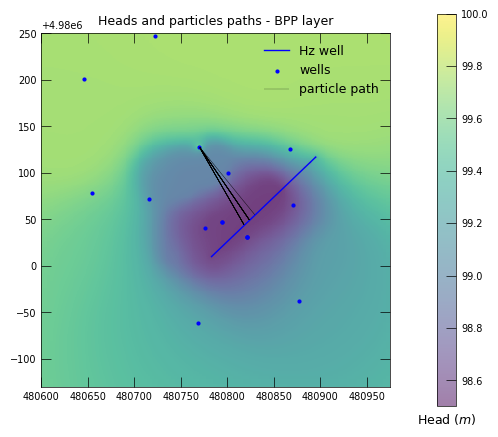

In [37]:
from matplotlib.patches import Patch

df = pd.read_csv("../data/wells_data.csv", index_col=0)
wells_site = df.loc[df.index != 'MLAC_center'].to_dict(orient='index')

wells_e = [coords['Easting'] for coords in wells_site.values()]
wells_n = [coords['Northing'] for coords in wells_site.values()]

pathlines_filtered = pathlines[pathlines['irpt'] % 500 == 0]

def plot_heads(ax, gwf, heads):
    mm = flopy.plot.PlotMapView(gwf, ax=ax, layer=1)
    #mm.plot_grid(alpha=0.25)
    #mm.plot_bc("WEL", plotAll=True, color="red")
    #mm.plot_bc("RIV", plotAll=True, color="blue")
    #mm.plot_bc("DRN", plotAll=True, color="green")
    pc = mm.plot_array(heads, 
                       #edgecolor="black", 
                       alpha=0.5)
    cb = plt.colorbar(pc, 
                      shrink=0.85, 
                      pad=0.1)
    cb.ax.set_xlabel(r"Head ($m$)")
    #ax.set_xlim(480533, 481001)
    #ax.set_ylim(4979834, 4980344)
    ax.set_xlim(480600, 480975)
    ax.set_ylim(4979870, 4980250)
    ax.plot([wells["horizontal_well"]["start_easting"], wells["horizontal_well"]["end_easting"]], 
             [wells["horizontal_well"]["start_northing"], wells["horizontal_well"]["end_northing"]], 
             'blue', label="Hz well", linewidth=1)
    ax.scatter(wells_e, wells_n, marker="o", color="blue", label="wells", s=4)
    ax.set_title("Heads and particles paths - BPP layer")

    
    
    mm.plot_pathline(
        pathlines_filtered, layer="all", colors="black", alpha=0.8, linewidth=0.2, label="particle path"
    )
    ax.legend()
    
    return mm


with flopy.plot.styles.USGSPlot():
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 6))
    ax.set_aspect("equal")
    ax.legend(
        #handles=[
            #Patch(color="red", label="Well"),
            #Patch(color="blue", label="River"),
            #Patch(color="green", label="Drain"),
        #],
    )
    #fig.tight_layout()
    #flopy.plot.styles.heading(ax, heading="Head, layer 2")
    mm = plot_heads(ax, gwf, head[1, :, :])
    
    '''mm.plot_pathline(
        pathlines, layer="all", colors="black", alpha=0.5, linewidth=0.2
    )'''
    

In [38]:
len(release_pts)

10000

In [39]:
pathlines

,kper,kstp,imdl,iprp,irpt,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name
0,1,1,2,1,1,2,199996,0,1,0,14.0,14.000000,6803.518460,6888.51846,-4.572000,NaN
1,1,1,2,1,2,2,199996,0,1,0,14.0,14.000000,6803.528460,6888.51846,-4.572000,NaN
2,1,1,2,1,3,2,199996,0,1,0,14.0,14.000000,6803.538460,6888.51846,-4.572000,NaN
3,1,1,2,1,4,2,199996,0,1,0,14.0,14.000000,6803.548460,6888.51846,-4.572000,NaN
4,1,1,2,1,5,2,199996,0,1,0,14.0,14.000000,6803.558460,6888.51846,-4.572000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2,20,2,1,9932,2,227992,0,5,3,14.0,20.957022,6863.804807,6817.51346,-4.574385,NaN
19996,2,20,2,1,9933,2,227992,0,5,3,14.0,20.891624,6863.796673,6817.51346,-4.573686,NaN
19997,2,20,2,1,9934,2,227992,0,5,3,14.0,20.820345,6863.788611,6817.51346,-4.572541,NaN
19998,2,20,2,1,9935,2,227992,0,5,3,14.0,20.707212,6863.781951,6817.51346,-4.569102,NaN


In [41]:
termination_pts = pathlines[pathlines.ireason == 3].set_index('irpt')

In [42]:
termination_pts

,kper,kstp,imdl,iprp,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name
irpt,,,,,,,,,,,,,,,
1,2,11,2,1,2,234570,0,5,3,14.0,17.786990,6845.890285,6800.51346,-4.557622,NaN
2,2,11,2,1,2,234570,0,5,3,14.0,17.787272,6845.894763,6800.51346,-4.557553,NaN
3,2,11,2,1,2,234570,0,5,3,14.0,17.787649,6845.899288,6800.51346,-4.557205,NaN
4,2,11,2,1,2,234570,0,5,3,14.0,17.786861,6845.903786,6800.51346,-4.556689,NaN
5,2,11,2,1,2,234570,0,5,3,14.0,17.785492,6845.908251,6800.51346,-4.556172,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9932,2,20,2,1,2,227992,0,5,3,14.0,20.957022,6863.804807,6817.51346,-4.574385,NaN
9933,2,20,2,1,2,227992,0,5,3,14.0,20.891624,6863.796673,6817.51346,-4.573686,NaN
9934,2,20,2,1,2,227992,0,5,3,14.0,20.820345,6863.788611,6817.51346,-4.572541,NaN


In [43]:
termination_pts['elapsed_time'] = termination_pts.t - termination_pts.trelease
termination_pts

,kper,kstp,imdl,iprp,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name,elapsed_time
irpt,,,,,,,,,,,,,,,,
1,2,11,2,1,2,234570,0,5,3,14.0,17.786990,6845.890285,6800.51346,-4.557622,NaN,3.786990
2,2,11,2,1,2,234570,0,5,3,14.0,17.787272,6845.894763,6800.51346,-4.557553,NaN,3.787272
3,2,11,2,1,2,234570,0,5,3,14.0,17.787649,6845.899288,6800.51346,-4.557205,NaN,3.787649
4,2,11,2,1,2,234570,0,5,3,14.0,17.786861,6845.903786,6800.51346,-4.556689,NaN,3.786861
5,2,11,2,1,2,234570,0,5,3,14.0,17.785492,6845.908251,6800.51346,-4.556172,NaN,3.785492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9932,2,20,2,1,2,227992,0,5,3,14.0,20.957022,6863.804807,6817.51346,-4.574385,NaN,6.957022
9933,2,20,2,1,2,227992,0,5,3,14.0,20.891624,6863.796673,6817.51346,-4.573686,NaN,6.891624
9934,2,20,2,1,2,227992,0,5,3,14.0,20.820345,6863.788611,6817.51346,-4.572541,NaN,6.820345


In [44]:
termination_pts.elapsed_time.describe()

count    10000.000000
mean         4.544026
std          0.830663
min          3.734200
25%          3.888669
50%          4.178782
75%          5.064614
max          7.000000
Name: elapsed_time, dtype: float64

<Axes: ylabel='Density'>

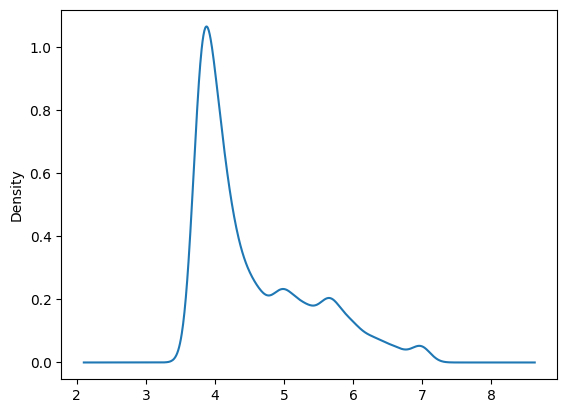

In [45]:
termination_pts.elapsed_time.plot(kind='kde')
#plt.xscale("log")
#plt.yscale("log")

BTC

In [46]:
n_bins = 200
time_bins = np.linspace(0, settings['tracking_days'], n_bins)
arrivals, _ = np.histogram(termination_pts['elapsed_time'], bins=time_bins)
mass = (arrivals / len(termination_pts)) * 2024 #2024 mg

Text(0.5, 1.0, 'Breakthrough Curve - porosity=0.0016')

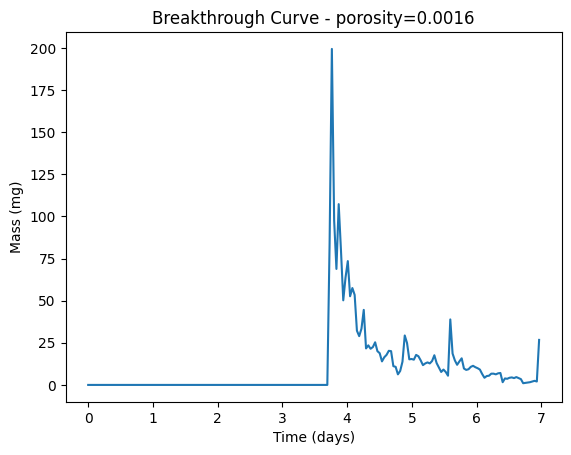

In [47]:
plt.plot(time_bins[:-1], mass)
#plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Time (days)")
plt.ylabel("Mass (mg)")
plt.title(f"Breakthrough Curve - porosity={porosity}")

Text(0.5, 1.0, 'Breakthrough Curve - porosity=0.0016')

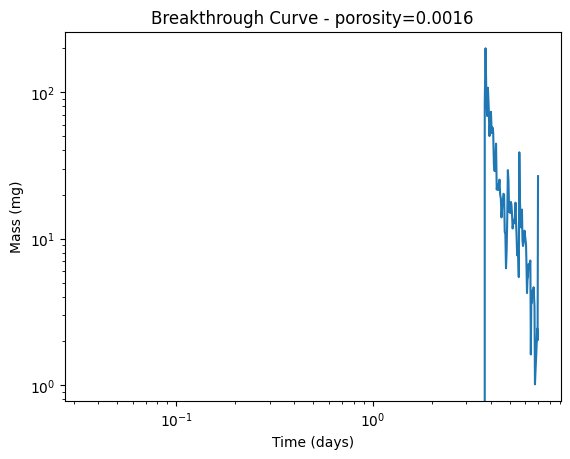

In [48]:
plt.plot(time_bins[:-1], mass)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Time (days)")
plt.ylabel("Mass (mg)")
plt.title(f"Breakthrough Curve - porosity={porosity}")

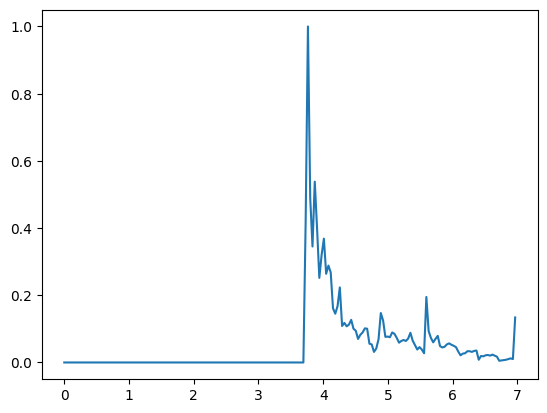

In [49]:
plt.plot(time_bins[:-1], mass/np.max(mass))

In [50]:
termination_pts['velocity_m_per_day'] = 92/termination_pts['elapsed_time']
termination_pts['Q_m3_day'] = termination_pts['velocity_m_per_day'] * porosity * 0.61  

In [51]:
termination_pts

,kper,kstp,imdl,iprp,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name,elapsed_time,velocity_m_per_day,Q_m3_day
irpt,,,,,,,,,,,,,,,,,,
1,2,11,2,1,2,234570,0,5,3,14.0,17.786990,6845.890285,6800.51346,-4.557622,NaN,3.786990,24.293698,0.023711
2,2,11,2,1,2,234570,0,5,3,14.0,17.787272,6845.894763,6800.51346,-4.557553,NaN,3.787272,24.291889,0.023709
3,2,11,2,1,2,234570,0,5,3,14.0,17.787649,6845.899288,6800.51346,-4.557205,NaN,3.787649,24.289476,0.023707
4,2,11,2,1,2,234570,0,5,3,14.0,17.786861,6845.903786,6800.51346,-4.556689,NaN,3.786861,24.294526,0.023711
5,2,11,2,1,2,234570,0,5,3,14.0,17.785492,6845.908251,6800.51346,-4.556172,NaN,3.785492,24.303316,0.023720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9932,2,20,2,1,2,227992,0,5,3,14.0,20.957022,6863.804807,6817.51346,-4.574385,NaN,6.957022,13.224048,0.012907
9933,2,20,2,1,2,227992,0,5,3,14.0,20.891624,6863.796673,6817.51346,-4.573686,NaN,6.891624,13.349538,0.013029
9934,2,20,2,1,2,227992,0,5,3,14.0,20.820345,6863.788611,6817.51346,-4.572541,NaN,6.820345,13.489054,0.013165


In [52]:
bin_width = settings['tracking_days']/n_bins

In [53]:
mean_flow_per_bin, _ = np.histogram(termination_pts['elapsed_time'], bins=time_bins, weights=termination_pts['Q_m3_day'])
count_per_bin, _ = np.histogram(termination_pts['elapsed_time'], bins=time_bins)
mean_flow = mean_flow_per_bin / count_per_bin

Text(0.5, 1.0, 'Breakthrough Curve - porosity=0.0016')

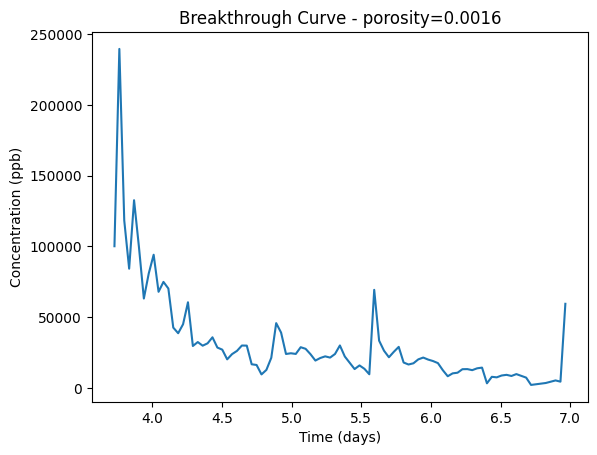

In [54]:

conc_ppb = (mass * 1.e+3) / (mean_flow * bin_width * 1.e+3)
plt.plot(time_bins[:-1], conc_ppb)
#plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Time (days)")
plt.ylabel("Concentration (ppb)")
plt.title(f"Breakthrough Curve - porosity={porosity}")

Text(0.5, 1.0, 'Breakthrough Curve - porosity=0.0016')

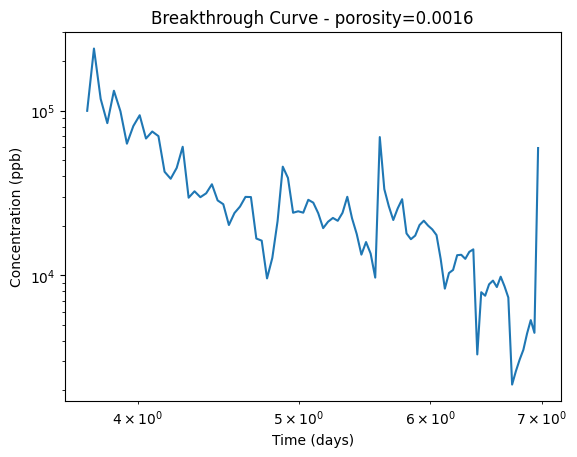

In [55]:
conc_ppb = (mass * 1.e+3) / (mean_flow * bin_width * 1.e+3)
plt.plot(time_bins[:-1], conc_ppb)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Time (days)")
plt.ylabel("Concentration (ppb)")
plt.title(f"Breakthrough Curve - porosity={porosity}")

Comparing field and simulated BTCs

In [58]:
data_22 = pd.read_csv('../data/field_BTCs/results_MLAC2022.csv')
data_23 = pd.read_csv('../data/field_BTCs/results_MLAC2023.csv')
data_24 = pd.read_csv('../data/field_BTCs/2024_BTC.csv')

In [59]:
conc_ppb

array([           nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
       7.97937888e+04, 7.15400952e+04, 3.62000722e+04, 2.23558778e+04,
       2.68984424e+04, 2.33845465e+04, 2.48285931e+04, 2.13073628e+04,
       1.28426013e+04, 9.66251639e+03, 5.37513598e+03, 4.34676013e+03,
       2.00197764e+03, 1.55536595e+03, 1.79322858e+02, 3.72090162e+02,
       6.43622968e+01, 1.34076604e+02, 6.87288110e+01,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
      

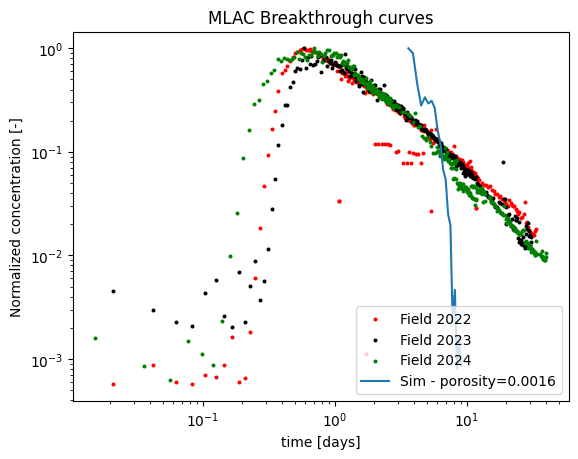

In [60]:
plt.scatter(data_22['time']/24, data_22['cnc_uranine']/data_22['cnc_uranine'].max(), label='Field 2022', color='red', s=3.5)
plt.scatter(data_23['time']/24, data_23['cnc_uranine']/data_23['cnc_uranine'].max(), label='Field 2023', color='k',  s=3.5)
plt.scatter(data_24['time (day)'], data_24[' concentration (ppb) ']/data_24[' concentration (ppb) '].max(), label='Field 2024', color='green', s=3.5)
#plt.plot(x, y, linestyle='--', color='k', linewidth=1.5)
#plt.plot(x2, y2, linestyle='--', color='red', linewidth=1.5)
#plt.plot(x3, y3, linestyle='--', color='green', linewidth=1.5)

plt.plot(time_bins[:-1], conc_ppb/np.nanmax(conc_ppb), label=f'Sim - porosity={porosity}')

plt.xlabel('time [days]')
plt.ylabel('Normalized concentration [-]')
plt.title('MLAC Breakthrough curves')
plt.xscale('log')
plt.yscale('log')
plt.legend()
#plt.text(1.8, 0.11, '1.10', color='red')
#plt.text(7.7, 0.44, '1.29', color='k')
#plt.text(0.49, 0.44, '1.27', color='green')
#plt.ylim(0.015, 1.6)
#plt.xlim(0.1, 40)
plt.show()

In [61]:
k_files_path

'C:/Users/lima0055/Documents/MLAC-3D-HT/src/pyemu/PMW-6-constantK/master_pp_newweights_newinitialK'

In [62]:
df_to_save = pd.DataFrame({'time': time_bins[:-1], 'normalized_conc': conc_ppb/np.nanmax(conc_ppb)})
#time_bins[:-1], conc_ppb/np.nanmax(conc_ppb)
df_to_save.head()

,time,normalized_conc
0,0.000000,NaN
1,0.301508,NaN
2,0.603015,NaN
3,0.904523,NaN
4,1.206030,NaN


In [63]:
df_to_save.to_csv('prior_sim_BTC.csv')

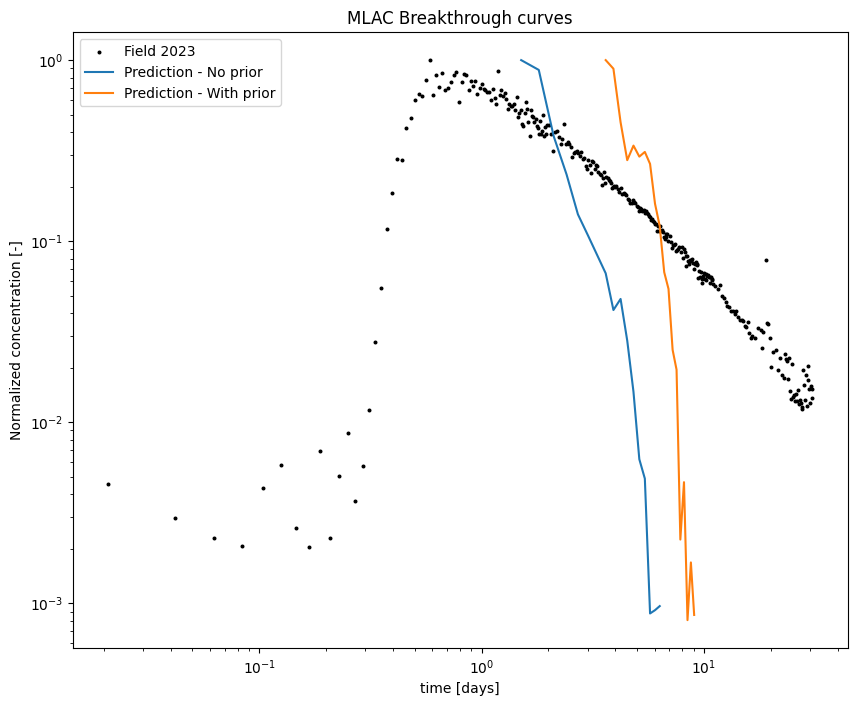

In [80]:
plt.figure(figsize=(10, 8))
#plt.scatter(data_22['time']/24, data_22['cnc_uranine']/data_22['cnc_uranine'].max(), label='Field 2022', color='red', s=3.5)
plt.scatter(data_23['time']/24, data_23['cnc_uranine']/data_23['cnc_uranine'].max(), label='Field 2023', color='k',  s=3.5)
#plt.scatter(data_24['time (day)'], data_24[' concentration (ppb) ']/data_24[' concentration (ppb) '].max(), label='Field 2024', color='green', s=3.5)
#plt.plot(x, y, linestyle='--', color='k', linewidth=1.5)
#plt.plot(x2, y2, linestyle='--', color='red', linewidth=1.5)
#plt.plot(x3, y3, linestyle='--', color='green', linewidth=1.5)
no_prior = pd.read_csv('no_prior_sim_BTC.csv')
prior = pd.read_csv('prior_sim_BTC.csv')

plt.plot(no_prior['time'], no_prior['normalized_conc'], label=f'Prediction - No prior')

plt.plot(prior['time'], prior['normalized_conc'], label=f'Prediction - With prior')


#plt.plot(time_bins[:-1], conc_ppb/np.nanmax(conc_ppb), label=f'Sim - porosity={porosity}')

plt.xlabel('time [days]')
plt.ylabel('Normalized concentration [-]')
plt.title('MLAC Breakthrough curves')
plt.xscale('log')
plt.yscale('log')
plt.legend(loc='upper left')
#plt.text(1.8, 0.11, '1.10', color='red')
#plt.text(7.7, 0.44, '1.29', color='k')
#plt.text(0.49, 0.44, '1.27', color='green')
#plt.ylim(0.015, 1.6)
#plt.xlim(0.1, 40)
plt.show()

In [64]:
try:
    import pyvista as pv
    from flopy.export.vtk import Vtk

    vert_exag = 10

    #vtk = Vtk(
        #model=gwf, binary=False, vertical_exageration=vert_exag, smooth=False
    #)
    #vtk.add_model(gwf)
    #vtk.add_pathline_points(mp7_pathlines.to_records(index=False))
    #gwf_mesh, mp7_mesh = vtk.to_pyvista()

    # this is a little awkward due to the design of `Vtk`, which can only
    # have one set of pathlines at a time.
    vtk = Vtk(
        model=gwf, binary=False, vertical_exageration=vert_exag, smooth=False
    )
    vtk.add_model(gwf)
    vtk.add_pathline_points(pathlines.to_records(index=False))
    gwf_mesh, prt_mesh = vtk.to_pyvista()

    def get_nn(k, i, j):
        """Convert a structured grid cell index to a node number."""
        return k * nrow * ncol + i * ncol + j

    # add meshes
    riv_mesh = pv.Box(
        bounds=[
            gwf.modelgrid.extent[1] - delc,
            gwf.modelgrid.extent[1],
            gwf.modelgrid.extent[2],
            gwf.modelgrid.extent[3],
            botm[0] * vert_exag,
            head[(0, 0, ncol - 1)] * vert_exag,
        ]
    )
    #well_cellid = get_nn(0, *wel_loc[1:])
    #well_points = gwf.modelgrid.verts[gwf.modelgrid.iverts[well_cellid]]
    #well_xs, well_ys = list(zip(*well_points))
    '''wel_mesh = pv.Box(
        bounds=[
            min(well_xs),
            max(well_xs),
            min(well_ys),
            max(well_ys),
            botm[-1] * vert_exag,
            botm[-2] * vert_exag,
        ]
    )'''
    bed_mesh = pv.Box(
        bounds=[
            gwf.modelgrid.extent[0],
            gwf.modelgrid.extent[1],
            gwf.modelgrid.extent[2],
            gwf.modelgrid.extent[3],
            botm[1] * vert_exag,
            botm[0] * vert_exag,
        ]
    )

    # create the plot
    axes = pv.Axes(show_actor=False, actor_scale=2.0, line_width=5)
    pv.set_jupyter_backend("static")
    # pv.set_jupyter_backend("trame")
    p = pv.Plotter(
        window_size=[500, 500],
        notebook=True,
    )
    p.enable_anti_aliasing()
    p.add_mesh(gwf_mesh, opacity=0.025, style="wireframe")
    '''p.add_mesh(
        mp7_mesh,
        point_size=5,
        line_width=2.5,
        smooth_shading=True,
        color="white",
    )'''
    p.add_mesh(
        prt_mesh,
        point_size=5,
        line_width=2.5,
        smooth_shading=True,
        color="gray",
    )
    p.add_mesh(riv_mesh, color="teal", opacity=0.2)
    #p.add_mesh(wel_mesh, color="red", opacity=0.3)
    p.add_mesh(bed_mesh, color="tan", opacity=0.1)
    p.show()
except:
    print("PyVista not found.")

PyVista not found.


In [65]:
#k_files_path = "C:/Users/lima0055/Documents/MLAC-3D-HT/src/pyemu/PMW-6-constantK/master_pp3_no_ss_no_prior"


In [66]:
k_files_path

'C:/Users/lima0055/Documents/MLAC-3D-HT/src/pyemu/PMW-6-constantK/master_pp_newweights_newinitialK'

In [67]:
hk1 = np.loadtxt(os.path.join(k_files_path, "k_layer1.txt"))
hk2 = np.loadtxt(os.path.join(k_files_path, "k_layer2.txt"))
hk3 = np.loadtxt(os.path.join(k_files_path, "k_layer3.txt"))

In [68]:
np.max(hk2)

np.float64(654.1793)

In [69]:
from scipy.stats import gmean

In [70]:
10**(np.mean(np.log10(hk3)))

np.float64(0.5782260732472413)

In [71]:
np.std(hk3)

np.float64(4.119113214929194)

In [72]:
((0.0092 * 12 * 1.e-3) / (9.8 * 998))**(1/2)

0.00010624444402518855